In [1]:
# Simulador básico de trayectorias espaciales bajo curvatura gravitacional (Fase 1)
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# Constantes
G = 6.67430e-11  # Constante gravitacional (m^3 kg^-1 s^-2)
M_sun = 1.989e30  # Masa del Sol (kg)

In [3]:
# Definir el campo gravitacional como una "curvatura" en el espacio
# Esta función devuelve la aceleración gravitacional

def gravedad(t, estado):
    x, y, vx, vy = estado
    r = np.sqrt(x**2 + y**2)
    ax = -G * M_sun * x / r**3
    ay = -G * M_sun * y / r**3
    return [vx, vy, ax, ay]

In [5]:
# Condiciones iniciales: posición (x, y) y velocidad (vx, vy)
# Ejemplo: nave saliendo desde la Tierra en dirección Marte
# Posición inicial a 1 AU del Sol (en metros)
AU = 1.496e11  # Unidad astronómica (m)

x0 = AU
y0 = 0
vx0 = 0
vy0 = 30000  # Velocidad inicial en m/s (30 km/s aprox)
estado_inicial = [x0, y0, vx0, vy0]

In [6]:
# Tiempo de simulación (segundos)
t_inicio = 0
t_final = 3.154e7  # 1 año

In [7]:
# Resolver ecuaciones diferenciales
sol = solve_ivp(gravedad, [t_inicio, t_final], estado_inicial, t_eval=np.linspace(t_inicio, t_final, 10000))


In [8]:
# Extraer resultados
x = sol.y[0]
y = sol.y[1]

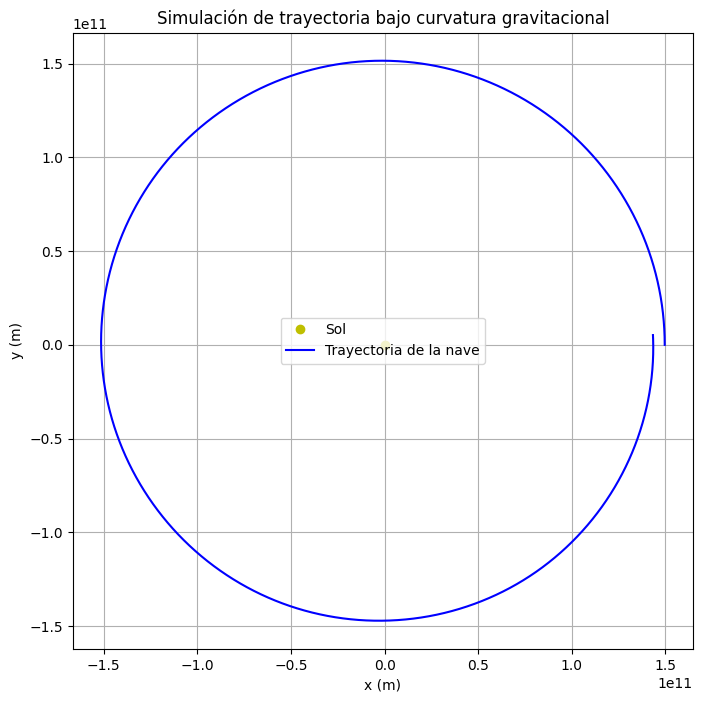

In [9]:
# Graficar trayectoria
plt.figure(figsize=(8, 8))
plt.plot(0, 0, 'yo', label='Sol')
plt.plot(x, y, 'b-', label='Trayectoria de la nave')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Simulación de trayectoria bajo curvatura gravitacional')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()
